# Install & Import

In [ ]:
!pip install optuna spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 14.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import optuna
import spacy

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load the Dataset

In [ ]:
import pandas as pd

file_path =  "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

# Contoh: anggap df sudah ada
# df['clean_text'], df['encoded_label']

X = df['clean_text'].astype(str)
y = df['encoded_label']

# ==========================
# Train–Val–Test Split
# ==========================

# Step 1: Test set 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: From remaining 80%, take 12.5% as validation
# 12.5% dari 80% = 10% dari total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 1445
Validation size: 207
Test size: 414


# Load spaCy Tokenizer (Indonesian)

In [ ]:
nlp = spacy.blank("id")   # tokenizer only, cepat
def spacy_tokenize(text):
    return [token.text for token in nlp(text)]


# Load FastText Embedding (300 dimensi)

In [ ]:
fasttext_path = "/content/drive/MyDrive/DistilBERT-7-Mei/cc.id.300.vec"

print("Loading FastText embedding...")
embeddings_index = {}

with open(fasttext_path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        values = line.rstrip().split(" ")
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print("Total words loaded:", len(embeddings_index))


Loading FastText embedding...
Total words loaded: 2000000


# Fungsi untuk mengubah kalimat → FastText sentence embedding

## Menggunakan mean pooling, adil dengan TF-IDF → vectorize.

In [ ]:
EMB_DIM = 300

def sentence_to_vector(text):
    tokens = spacy_tokenize(text)
    vectors = []

    for token in tokens:
        if token in embeddings_index:
            vectors.append(embeddings_index[token])

    if len(vectors) == 0:
        return np.zeros(EMB_DIM)

    return np.mean(vectors, axis=0)


## Convert dataset jadi embedding matrix:

In [ ]:
def convert_dataset(texts):
    return np.vstack([sentence_to_vector(t) for t in texts])


# Convert Train / Val / Test ke FastText embedding

In [ ]:
X_train_vec = convert_dataset(X_train)
X_val_vec   = convert_dataset(X_val)
X_test_vec  = convert_dataset(X_test)

print("Train shape:", X_train_vec.shape)
print("Val shape:", X_val_vec.shape)
print("Test shape:", X_test_vec.shape)


Train shape: (1445, 300)
Val shape: (207, 300)
Test shape: (414, 300)


# Optuna Objective


In [ ]:
def objective(trial):
    # Hyperparameter search
    C = trial.suggest_float("C", 1e-3, 10, log=True)
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
    gamma = trial.suggest_float("gamma", 1e-4, 1.0, log=True) if kernel == "rbf" else "scale"

    # Model
    model = SVC(
        C=C,
        kernel=kernel,
        gamma=gamma,
        probability=True,
        random_state=42
    )

    # Train langsung (tanpa k-fold)
    model.fit(X_train_vec, y_train)

    # Prediksi pada validation set
    preds = model.predict(X_val_vec)

    # Return f1-score
    return f1_score(y_val, preds)


# Run Optuna

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best Params:", study.best_params)
best_params = study.best_params


[I 2025-11-25 06:28:13,779] A new study created in memory with name: no-name-9782d797-f07f-4ee4-8f91-c64a03e4e495
[I 2025-11-25 06:28:16,146] Trial 0 finished with value: 0.0 and parameters: {'C': 0.017460718391767268, 'kernel': 'rbf', 'gamma': 0.277252929280317}. Best is trial 0 with value: 0.0.
[I 2025-11-25 06:28:17,952] Trial 1 finished with value: 0.0 and parameters: {'C': 0.010238748435696379, 'kernel': 'linear'}. Best is trial 0 with value: 0.0.
[I 2025-11-25 06:28:19,237] Trial 2 finished with value: 0.7953216374269005 and parameters: {'C': 0.6255196538926895, 'kernel': 'linear'}. Best is trial 2 with value: 0.7953216374269005.
[I 2025-11-25 06:28:20,453] Trial 3 finished with value: 0.45528455284552843 and parameters: {'C': 0.0773065151471119, 'kernel': 'linear'}. Best is trial 2 with value: 0.7953216374269005.
[I 2025-11-25 06:28:21,221] Trial 4 finished with value: 0.8397790055248618 and parameters: {'C': 7.6293220867485365, 'kernel': 'linear'}. Best is trial 4 with value: 0

Best Params: {'C': 8.526364892967143, 'kernel': 'linear'}


# Train Final Model (Train + Val)

In [ ]:
best_C = best_params["C"]
best_kernel = best_params["kernel"]
best_gamma = best_params["gamma"] if best_kernel == "rbf" else "scale"

final_model = SVC(C=best_C, kernel=best_kernel, gamma=best_gamma, probability=True,
    random_state=42)

X_final = np.vstack([X_train_vec, X_val_vec])
y_final = np.concatenate([y_train.values, y_val.values])

final_model.fit(X_final, y_final)


SVC(C=8.526364892967143, kernel='linear', probability=True, random_state=42)

# Evaluate on Test Set

Mapping encoded_label -> class name:
0.0 -> Bullying
1.0 -> Non-bullying

Class names (sorted by encoded_label):
['Bullying', 'Non-bullying']

 Final Model F1 Score (Test, macro): 0.8294

 Classification Report:

              precision    recall  f1-score   support

    Bullying     0.8193    0.8947    0.8553       228
Non-bullying     0.8545    0.7581    0.8034       186

    accuracy                         0.8333       414
   macro avg     0.8369    0.8264    0.8294       414
weighted avg     0.8351    0.8333    0.8320       414



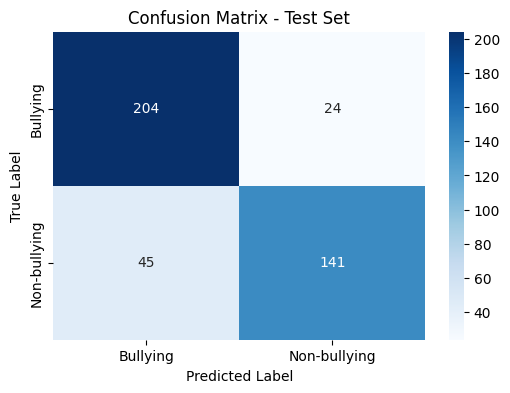

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ================================
# 1. Prediction
# ================================
y_pred = final_model.predict(X_test_vec)

# ================================
# 2. Mapping Label (agar rapi)
# ================================
label_mapping = {
    0.0: "Bullying",
    1.0: "Non-bullying"
}

class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]

print("Mapping encoded_label -> class name:")
for k, v in label_mapping.items():
    print(f"{k} -> {v}")

print("\nClass names (sorted by encoded_label):")
print(class_names)

# ================================
# 3. Evaluasi F1
# ================================
f1 = f1_score(y_test, y_pred, average="macro")
print(f"\n Final Model F1 Score (Test, macro): {f1:.4f}")

# ================================
# 4. Classification Report
# ================================
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# ================================
# 5. Confusion Matrix + Heatmap
# ================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.show()


# Save Model Configuration Summary :

In [ ]:
import json
from pprint import pprint

experiment_config = {
    "tokenizer": "spacy",
    "embedding": "fasttext",
    "model": "svm",
    "svm_C": best_C,
    "svm_kernel": best_kernel,
    "svm_gamma": best_gamma,
    "embedding_dim": EMB_DIM
}

print("\nExperiment Configuration:")
pprint(experiment_config)

print("\nJSON Format:")
print(json.dumps(experiment_config, indent=4))

print("\nFinal Macro F1:", f"{f1:.4f}")



Experiment Configuration:
{'embedding': 'fasttext',
 'embedding_dim': 300,
 'model': 'svm',
 'svm_C': 8.526364892967143,
 'svm_gamma': 'scale',
 'svm_kernel': 'linear',
 'tokenizer': 'spacy'}

JSON Format:
{
    "tokenizer": "spacy",
    "embedding": "fasttext",
    "model": "svm",
    "svm_C": 8.526364892967143,
    "svm_kernel": "linear",
    "svm_gamma": "scale",
    "embedding_dim": 300
}

Final Macro F1: 0.8294
